<b>Exploratory Data Analysis and Prediction of Alcohol-Related Road Accidents in Hungary Using Official Statistical Data</b>

This project examines the development of alcohol-related road accidents in Hungary using publicly available data* from the Hungarian Central Statistical Office. The analysis is based on the following datasets: the number of registered passenger vehicles, the estimated number of alcohol-dependent individuals, total road accidents, and accidents caused by intoxicated drivers.

1. As a first step, an exploratory data analysis is conducted to identify key statistical characteristics and long-term trends. Descriptive statistics, visualizations, and correlation analysis are used to better understand how changes in traffic volume and alcohol-related indicators are associated with accident patterns. A key focus of the analysis is to assess whether the zero-tolerance policy introduced in 2008 led to a measurable improvement in trends and contributed to the reduction of alcohol-related accidents.

2. Based on these findings, a simple predictive model is developed using the available explanatory variables to estimate the evolution of alcohol-related accidents over time.

3. Finally, the results are interpreted from a road safety perspective, with particular emphasis on the role of regulatory measures and broader societal factors influencing alcohol-related traffic incidents.

*Data sources:<br>
	•	Road accidents involving personal injury by cause: https://www.ksh.hu/stadat_files/ege/hu/ege0064.html<br>
	•	Passenger car stock by brand and fuel type: https://www.ksh.hu/stadat_files/sza/hu/sza0025.html<br>
	•	Road accidents involving intoxicated drivers: https://www.ksh.hu/stadat_files/ege/hu/ege0066.html<br>
	•	Care of alcohol-dependent individuals: https://www.ksh.hu/stadat_files/ege/hu/ege0030.html<br>
	•	Outpatient treatment due to alcohol-related mental and behavioral disorders: https://www.ksh.hu/stadat_files/ege/hu/ege0085.html<br>

<b>Loading and cleaning the data</b><br><br>
Before starting the analysis, the datasets need to be cleaned and aligned.
The year ranges must be made consistent by keeping only the years that appear in all tables.

Two alcohol dependence datasets need to be merged, since one contains earlier estimates and the other continues them in later years, with an overlap between the two. A normalized indicator is created for intoxicated accidents / 100,000 cars to account for the growing number of vehicles over time. 

Once this is done, the tables can be combined into a single dataset.

In [48]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root / "src"))

import importlib
import load_data
importlib.reload(load_data)

from load_data import load_road_accidents, load_intoxicated_accidents, load_personal_cars, load_alcohol_dependence, load_alcohol_treatment

intoxicated_accidents = load_intoxicated_accidents("../data/ittasan_okozott_szemelyseruleses_balesetek.csv")
personal_cars = load_personal_cars("../data/szemelygepjarmu_allomany.csv")
road_injuries = load_road_accidents("../data/szemelyseruleses_kozlekedesi_balesetek.csv")
dependence_estimate_prev = load_alcohol_dependence("../data/alkoholistak_gondozas.csv")
dependence_estimate_fresh = load_alcohol_treatment("../data/alkohol_szakellatas.csv")

import clean_data
importlib.reload(clean_data)

from clean_data import merge_alcohol_data, merge_all_data, normalize_accidents, describe_intoxicated_rate

alcohol = merge_alcohol_data(dependence_estimate_prev, dependence_estimate_fresh)
dataFrame = merge_all_data(intoxicated_accidents, road_injuries, personal_cars, alcohol)
dataFrame = normalize_accidents(dataFrame)
dataFrame = describe_intoxicated_rate(dataFrame)

<b>Explanatory Data Analysis (EDA)</b>


Timed Plots


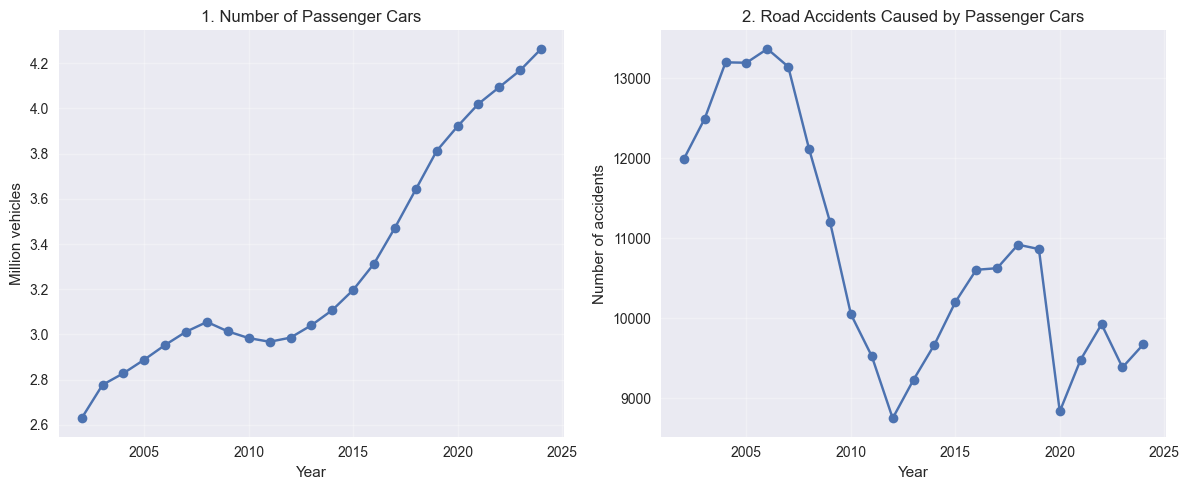

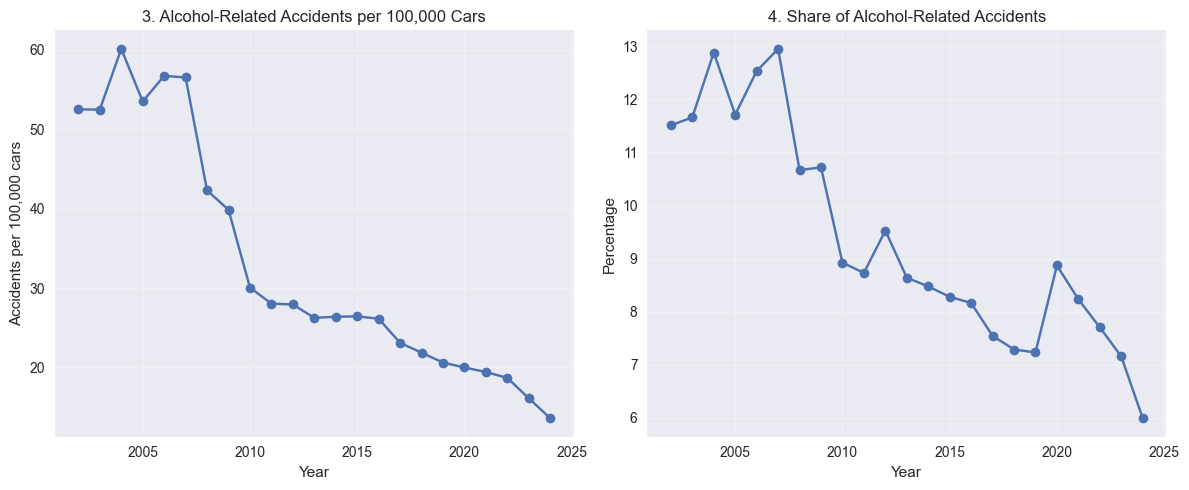

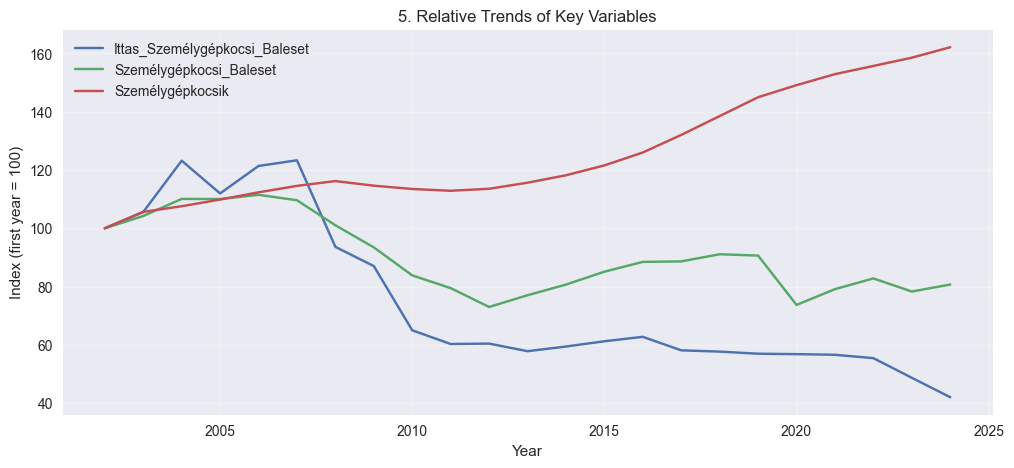

In [49]:
import eda
importlib.reload(eda)

from eda import plot_indexed_series, plot_double

print("\nTimed Plots")

dataFrame["Személygépkocsik_Millió"] = dataFrame["Személygépkocsik"] / 1_000_000

plot_double(
    dataFrame=dataFrame,
    col1="Személygépkocsik_Millió",
    col2="Személygépkocsi_Baleset",
    title1="1. Number of Passenger Cars",
    title2="2. Road Accidents Caused by Passenger Cars",
    xlabel="Year",
    ylabel1="Million vehicles",
    ylabel2="Number of accidents"
)

plot_double(
    dataFrame=dataFrame,
    col1="Ittas_Baleset_100ezer_Autóra",
    col2="Ittas_Baleset_Arány",
    title1="3. Alcohol-Related Accidents per 100,000 Cars",
    title2="4. Share of Alcohol-Related Accidents",
    xlabel="Year",
    ylabel1="Accidents per 100,000 cars",
    ylabel2="Percentage"
)

plot_indexed_series(
    dataFrame,
    [
        "Ittas_Személygépkocsi_Baleset",
        "Személygépkocsi_Baleset",
        "Személygépkocsik"
    ],
    "5. Relative Trends of Key Variables",
    xlabel="Year",
    ylabel="Index (first year = 100)"
)

<b>Key Findings:</b>

Figures 1–2 (Number of Passenger Cars, Road Accidents Caused by Passenger Cars): The number of passenger cars — representing the primary exposure level — increased steadily and significantly over the observed period (from approximately 2.6 million to 4.2 million). In contrast, the number of injury-related road accidents declined. This suggests that the reduction in accidents cannot be explained by a decrease in traffic exposure or fewer opportunities for accidents to occur.

Figure 2 (Road Accidents Caused by Passenger Cars): Despite the substantial growth in the vehicle fleet, the number of injury-related accidents decreased (from around 12,000 to 10,000). This trend is likely driven by several factors, including advancements in vehicle safety technologies, improvements in road infrastructure (such as road quality and signaling), and changes in the regulatory environment.
   
Figure 3 (Alcohol-Related Accidents per 100,000 Cars): Using raw counts alone would distort the analysis due to the significant increase in both the number of vehicles and total accidents. To address this, a normalized indicator — alcohol-related injury accidents per 100,000 cars — was constructed. This measure shows that alcohol-related accidents are genuinely declining relative to the size of the driving population.

Figure 4 (Share of Alcohol-Related Accidents): Examining the composition of accidents reveals that the proportion of alcohol-related incidents has steadily decreased (from approximately 11% to 6%). This suggests a shift in driver behavior and overall driving culture over the observed period.

---


Correlation Analysis


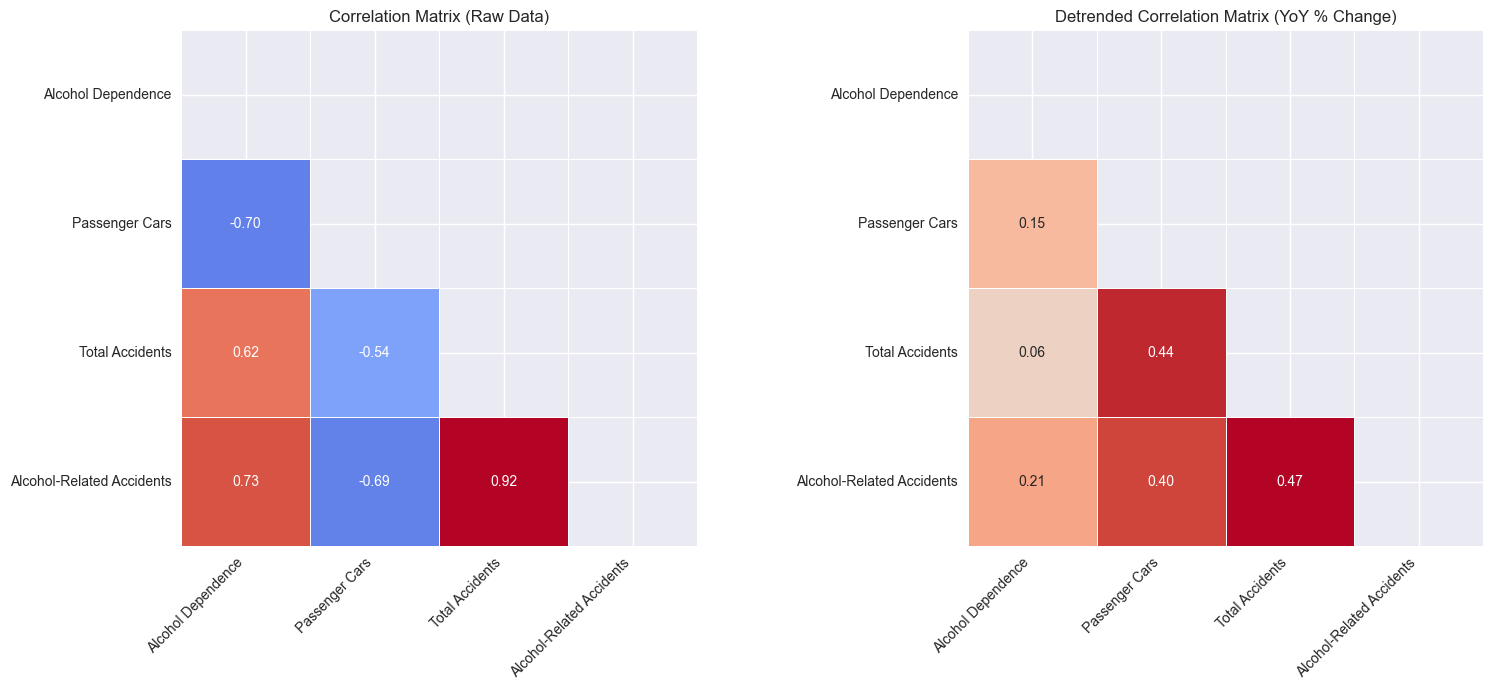

In [50]:
print("\nCorrelation Analysis")

label_map = {
    "Alkoholfüggők_becsült_száma": "Alcohol Dependence",
    "Személygépkocsik": "Passenger Cars",
    "Személygépkocsi_Baleset": "Total Accidents",
    "Ittas_Személygépkocsi_Baleset": "Alcohol-Related Accidents"
}

eda.plot_dual_correlation_matrix(
    dataFrame,
    [
        "Alkoholfüggők_becsült_száma",
        "Személygépkocsik",
        "Személygépkocsi_Baleset",
        "Ittas_Személygépkocsi_Baleset",
    ],
    [
        "Correlation Matrix (Raw Data)",
        "Detrended Correlation Matrix (YoY % Change)"
    ],
    label_map=label_map
)

<b>Key Findings:<b>

1. Matrix (Correlation Matrix – Raw Data): This “raw” correlation matrix leads to a classic analytical pitfall. Since it examines variables over a 20+ year period, it shows strong positive and negative correlations (e.g., a −0.70 correlation between the number of cars and alcohol-related injury accidents). However, because all variables evolve along the same timeline, this can result in misleading conclusions — such as assuming that the increase in the number of cars is strongly related to the decrease in alcohol-related accidents. In reality, both changes simply occurred over the same time period, without necessarily implying a direct causal relationship.

2. Matrix (Detrended Correlation Matrix): By removing the time trend (using year-over-year percentage changes), we can analyze how variables move together from one year to the next. The results show that correlations decrease significantly after detrending.

    - Total accidents vs. alcohol-related accidents (from 0.92 to 0.47): Although this remains the strongest relationship, a correlation of 0.47 is far from perfect. This suggests that in years with worse overall conditions (e.g., severe weather), both total and alcohol-related accidents may increase together. At the same time, the weaker correlation indicates that alcohol-related accidents also follow their own distinct dynamics.

    - Estimated number of alcohol-dependent individuals vs. alcohol-related accidents (from 0.73 to 0.21): While the raw data suggested a strong relationship, detrending reveals that short-term increases in alcohol dependence do not immediately translate into spikes in alcohol-related accidents. It is worth noting, however, that this variable is based on estimates, which introduces additional uncertainty into the analysis.

---


Scatter Plots


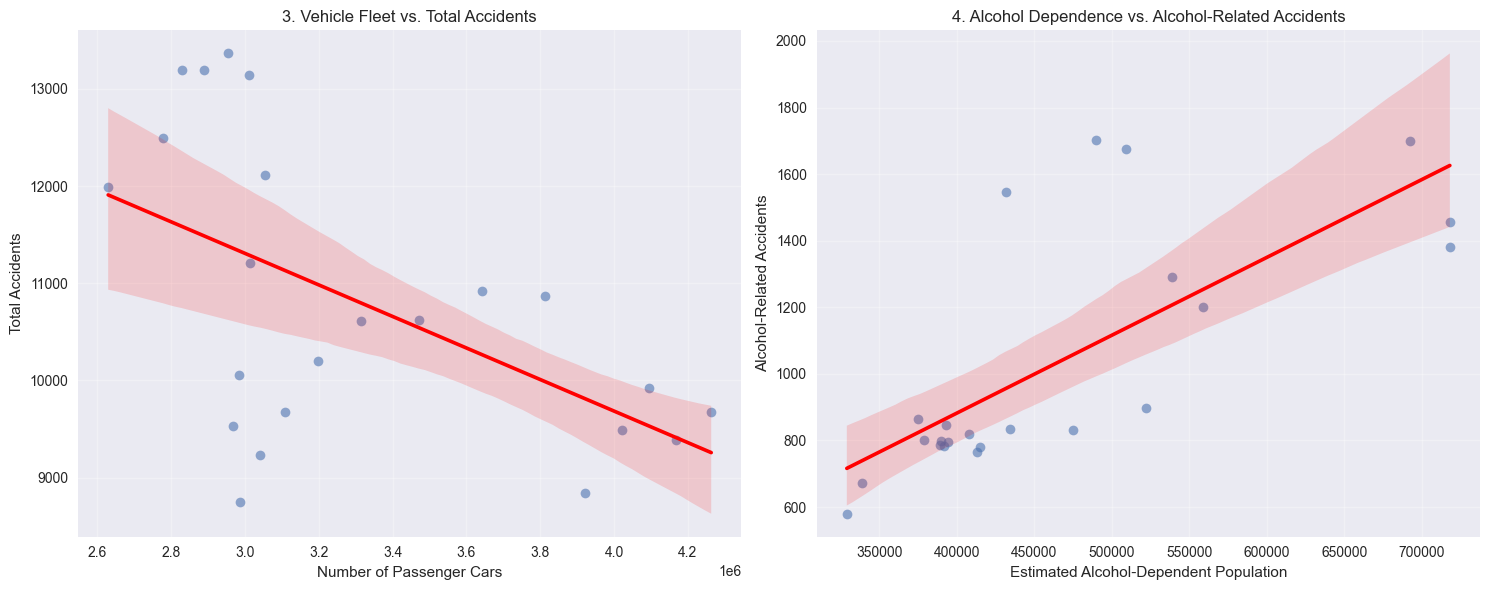

In [51]:
print("\nScatter Plots")

eda.plot_comparative_scatters(
    dataFrame,
    x_variables=["Személygépkocsik", "Alkoholfüggők_becsült_száma"],
    y_variables=["Személygépkocsi_Baleset", "Ittas_Személygépkocsi_Baleset"],
    titles=[
        "3. Vehicle Fleet vs. Total Accidents",
        "4. Alcohol Dependence vs. Alcohol-Related Accidents"
    ],
    xlabels=[
        "Number of Passenger Cars",
        "Estimated Alcohol-Dependent Population"
    ],
    ylabels=[
        "Total Accidents",
        "Alcohol-Related Accidents"
    ]
)

<b>Key Findings:</b>

1. Scatter Plot (Vehicle Fleet vs. Total Accidents): At first glance, the plot suggests that more cars are associated with fewer accidents. However, this is a spurious relationship. It is not the increase in the number of vehicles that reduces accidents, but rather the effect of time: over the past two decades, while the number of cars has increased, both vehicle safety and infrastructure have improved significantly.

2. Scatter Plot (Alcohol Dependence vs. Alcohol-Related Accidents): The regression line shows a positive relationship (more alcohol dependence is associated with more accidents), but the key insight lies in the dispersion of the data. At lower values, the points are tightly clustered, indicating a clearer relationship. However, at higher levels (above ~500,000), the spread becomes much larger, suggesting that extreme values are difficult to predict reliably using this variable alone.

---


Potential Breakpoints


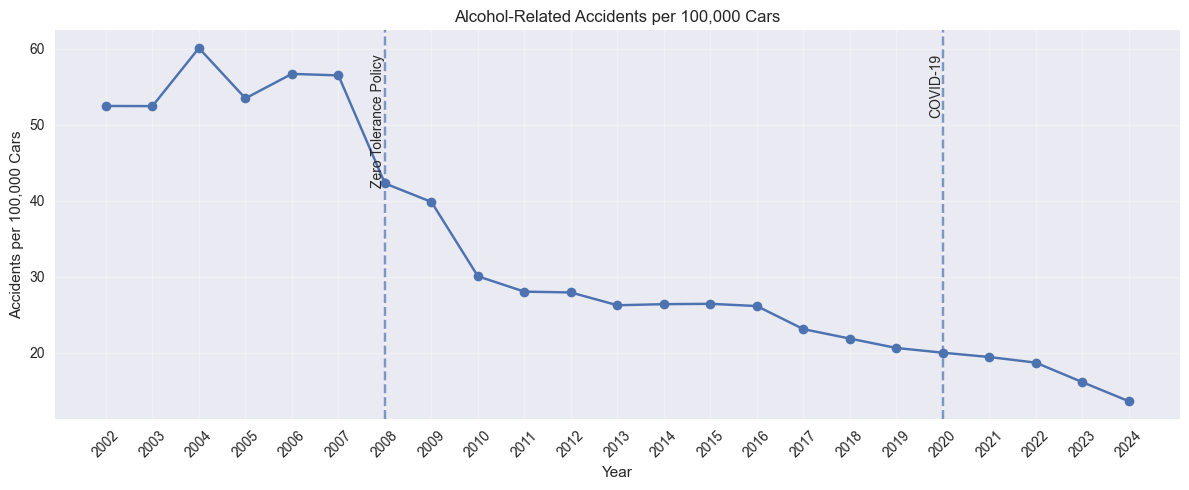

In [53]:
print("\nPotential Breakpoints")

from eda import plot_time_series

plot_time_series(
    dataFrame,
    "Ittas_Baleset_100ezer_Autóra",
    "Alcohol-Related Accidents per 100,000 Cars",
    "Accidents per 100,000 Cars",
    breakpoints=[
        (2008, "Zero Tolerance Policy"),
        (2020, "COVID-19")
    ],
    xlabel="Year"
)

<b>Key Findings:</b>

1. Introduction of Zero Tolerance Policy (2008): Following the introduction of the policy, the indicator dropped from 56 to 42. This sharp decline suggests that strict and immediate penalties led to a rapid behavioral change among drivers.

2. COVID-19 (2020): The lockdown period did not result in a significant deviation from the existing trend. The chart shows that the steady long-term decline, which began after the 2008 structural break, remained largely stable even during the pandemic.

----


Scatter Plots for Lag Analysis


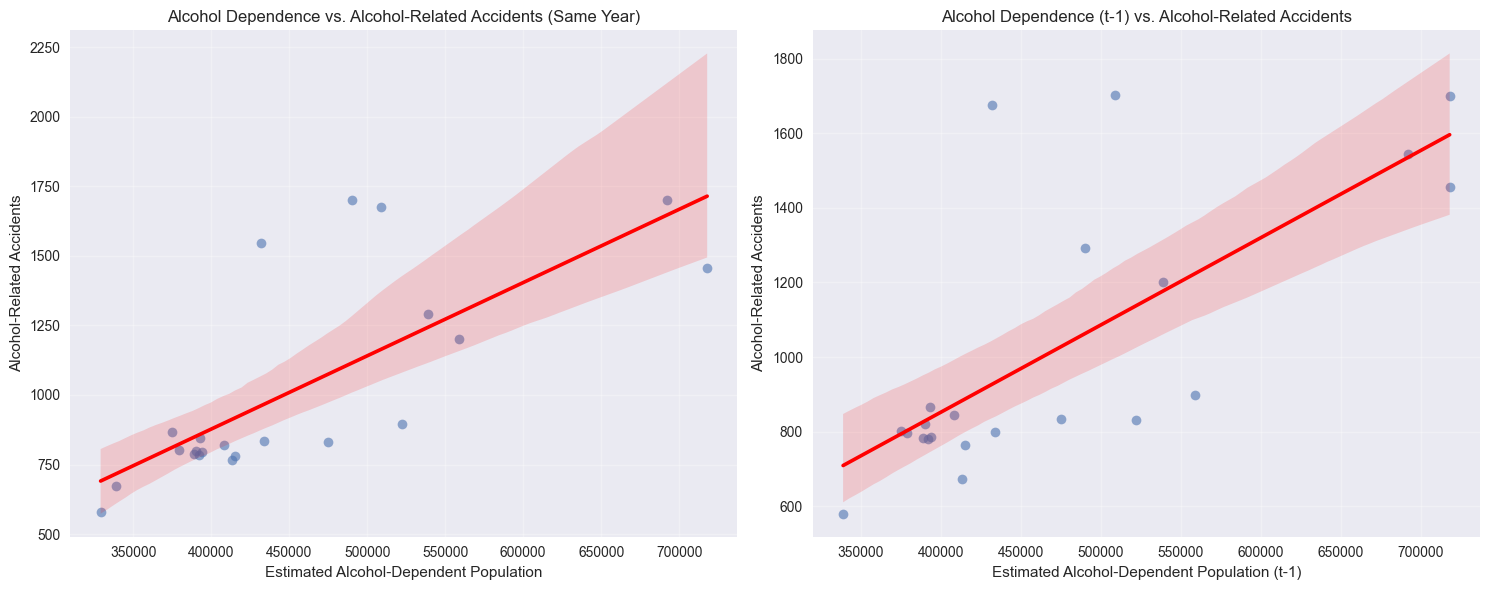

Same-year correlation: 0.7384448223421316, Lagged correlation (1 year): 0.7231345784177443


In [57]:
print("\nScatter Plots for Lag Analysis")

df_lag = dataFrame.copy()
df_lag["Alkoholfüggők_lag1"] = df_lag["Alkoholfüggők_becsült_száma"].shift(1)
df_lag = df_lag.dropna()

eda.plot_comparative_scatters(
    df_lag,
    x_variables=[
        "Alkoholfüggők_becsült_száma",
        "Alkoholfüggők_lag1"
    ],
    y_variables=[
        "Ittas_Személygépkocsi_Baleset",
        "Ittas_Személygépkocsi_Baleset"
    ],
    titles=[
        "Alcohol Dependence vs. Alcohol-Related Accidents (Same Year)",
        "Alcohol Dependence (t-1) vs. Alcohol-Related Accidents"
    ],
    xlabels=[
        "Estimated Alcohol-Dependent Population",
        "Estimated Alcohol-Dependent Population (t-1)"
    ],
    ylabels=[
        "Alcohol-Related Accidents",
        "Alcohol-Related Accidents"
    ]
)

print(f"Same-year correlation: {val1}, Lagged correlation (1 year): {val2}")

<b>Key Findings:</b>

This pair of scatter plots illustrates the relationship between the estimated number of alcohol-dependent individuals and alcohol-related accidents, each with a fitted trend line. The left plot uses same-year data, while the right plot uses a one-year lag.

Result: The two correlation values are nearly identical (0.738 for the same year and 0.723 with a one-year lag). The dispersion of the data points is also visually very similar across the two plots.

Conclusion: We tested the hypothesis that alcohol dependence, as a longer-term process, might better predict accidents in the following year. The results do not support this assumption: introducing a one-year lag (t-1) does not strengthen the relationship and does not improve the model’s predictive power. In other words, last year’s alcohol dependence data does not provide a more accurate prediction of current-year accidents than same-year data. It should also be noted that the estimated nature of the alcohol dependence data introduces additional uncertainty into these results.

---

Intercept: 68.731
R² Score: 0.963

Coefficients:
                   Variable  Coefficient
0                Time Trend    -1.504629
1  Alcohol Dependence (t-1)    -0.000014
2     Zero Tolerance Policy   -16.705444


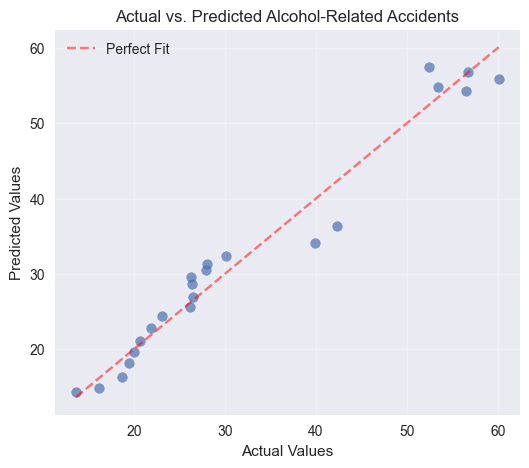

In [67]:
import importlib
import predictive_model
importlib.reload(predictive_model)

from predictive_model import prepare_model_data, forecast_model, compare_models, showcase_model_results, forecast_and_plot_future

model_df = prepare_model_data(dataFrame)

model, predictors, actual_accidents, predicted_accidents, r2 = forecast_model(
    model_df,
    "Ittas_Baleset_100ezer_Autóra",
    [
        "Trend",
        "Alkoholfüggők_lag1",
        "Zéró_Tolerancia"
    ]
)

showcase_model_results(
    model,
    predictors,
    actual_accidents,
    predicted_accidents,
    r2,
    "Actual vs. Predicted Alcohol-Related Accidents",
    language="en",
    label_map={
        "Trend": "Time Trend",
        "Alkoholfüggők_lag1": "Alcohol Dependence (t-1)",
        "Zéró_Tolerancia": "Zero Tolerance Policy"
    }
)

<b>Interpretation of Results</b>
1. Intercept: Since the trend variable represents time, the intercept value (~68) reflects the baseline level of alcohol-related accidents at the beginning of the observed period.
   
2. Coefficient of Determination (R²): The value (~0.96) is relatively high, indicating that the model fits the historical data closely. However, it is important to note that the Trend variable acts as a composite indicator: it captures all time-related factors that are not explicitly measured (such as technological improvements, infrastructure development, etc.). Therefore, the 96.3% explained variance suggests that the selected variables together with the time trend account for most of the variation in accident data, but it is likely that unidentified external factors are embedded within this trend.

   
3. Coefficients:<br>
	•	Trend (-1.505):
Each additional year is associated with an average decrease of approximately 1.5 alcohol-related accidents per 100,000 cars.<br><br>
	•	Zero Tolerance Policy (-16.705):
Since this is a binary indicator (0 before the law, 1 after), the coefficient reflects the direct effect of the regulation. The introduction of the policy is associated with a significant reduction in alcohol-related accidents per 100,000 cars.<br><br>
	•	Alcohol Dependence (t-1) (-0.000014):
This value is effectively zero, indicating that year-to-year changes in the estimated number of alcohol-dependent individuals have a negligible direct impact on accident numbers.<br>

---

,Model,R2,Trend,Zéró_Tolerancia,Alkoholfüggők_lag1
0,Trend Only,0.859,-2.1118,,
1,Trend + Zero Tolerance Policy,0.960,-1.3473,-15.9285,
2,Trend + Zero Tolerance + Alcohol Dependence,0.963,-1.5046,-16.7054,-0.0


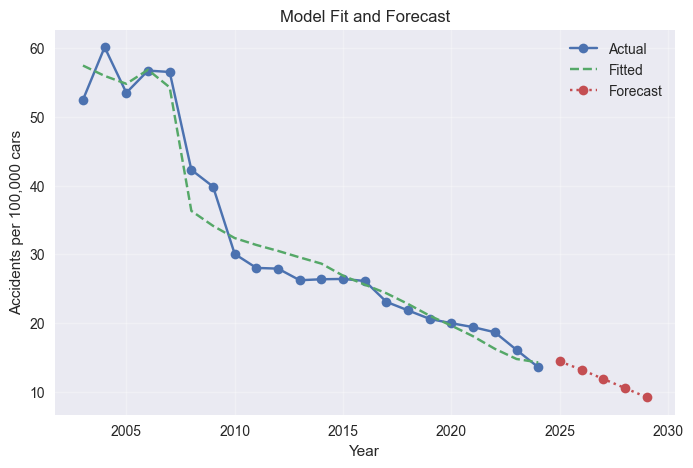

In [71]:
label_map = {
    "Trend": "Time Trend",
    "Alkoholfüggők_lag1": "Alcohol Dependence (t-1)",
    "Zéró_Tolerancia": "Zero Tolerance Policy"
}

predictive_model.comparison = compare_models(
    model_df,
    "Ittas_Baleset_100ezer_Autóra",
    model_specs,
    label_map=label_map
)

display(comparison)

future_df = predictive_model.forecast_and_plot_future(
    model_df,
    model,
    ["Trend", "Alkoholfüggők_lag1", "Zéró_Tolerancia"],
    actual_accidents,
    predicted_accidents,
    years_ahead=5,
    language="en",
    ylabel="Accidents per 100,000 cars"
)

<b> Key Takeaways </b>

1.	Immediate effect of zero tolerance (power of legal regulation)

Our predictive model clearly demonstrates the success of the 2008 tightening of legislation.
Incorporating the law into the model increased the prediction accuracy from 85.9% to 96% ($R^2$). The coefficient of -15.9 indicates that the introduction of zero tolerance alone immediately reduced the number of drunk-driving accidents by almost 16 per 100,000 vehicles.

2. General improvement in traffic safety (role of the trend)

Beyond the legislative “shock,” our model also revealed a continuous positive effect over time. As vehicles and infrastructure improved and driving culture evolved, the accident rate decreased steadily on its own (with an average annual coefficient of -1.5 even in the period after the law was introduced).

3. Limited suitability of health estimates for prediction (inaccurate data)

Although there is an observable correlation between alcoholism statistics and accident numbers, this variable did not add predictive accuracy beyond the trend and legislative variables in our model. This may point to inaccuracies in health data, or indicate that changes in addiction rates are a slower process than what a yearly-based traffic model can capture.